# 03 Patient Segmentation

## Goal
Identify clinically meaningful geriatric patient segments using healthcare utilization, condition burden, medication burden, and healthcare resource indicators.

## Questions
1. Can geriatric patients be grouped into distinct segments based on healthcare complexity and utilization?
2. Which segments appear to represent higher-risk or potentially underserved populations?
3. How can these segments support targeted interventions or care strategies?

In [1]:
#1: Load the processed dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

DATA_PATH = Path("../data/processed/patient_level_analytics.csv")
df = pd.read_csv(DATA_PATH)

df.head()
df.shape

(31, 42)

In [2]:
#2: Choosing the right clustering features
cluster_features = [
    "age",
    "healthcare_expenses",
    "healthcare_coverage",
    "income",
    "total_encounters",
    "hospitalization_count",
    "total_conditions",
    "unique_conditions",
    "total_medications",
    "unique_medications",
    "total_claims",
    "total_observations"
]

In [3]:
#3: Create clustering dataset
X = df[cluster_features].copy()
X.info()
X.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    31 non-null     float64
 1   healthcare_expenses    31 non-null     float64
 2   healthcare_coverage    31 non-null     float64
 3   income                 31 non-null     int64  
 4   total_encounters       31 non-null     int64  
 5   hospitalization_count  31 non-null     int64  
 6   total_conditions       31 non-null     int64  
 7   unique_conditions      31 non-null     int64  
 8   total_medications      31 non-null     int64  
 9   unique_medications     31 non-null     int64  
 10  total_claims           31 non-null     int64  
 11  total_observations     31 non-null     int64  
dtypes: float64(3), int64(9)
memory usage: 3.0 KB


age                      0
healthcare_expenses      0
healthcare_coverage      0
income                   0
total_encounters         0
hospitalization_count    0
total_conditions         0
unique_conditions        0
total_medications        0
unique_medications       0
total_claims             0
total_observations       0
dtype: int64

In [4]:
#fill missing values:

X = X.fillna(0)

In [5]:
#4: Scaling  the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

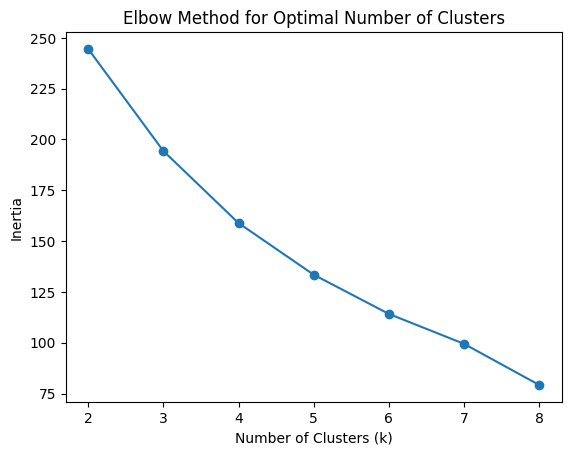

In [6]:
#5: Finding a reasonable number of clusters: Using both the elbow method and silhouette score to decide on k.
inertia = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.show()

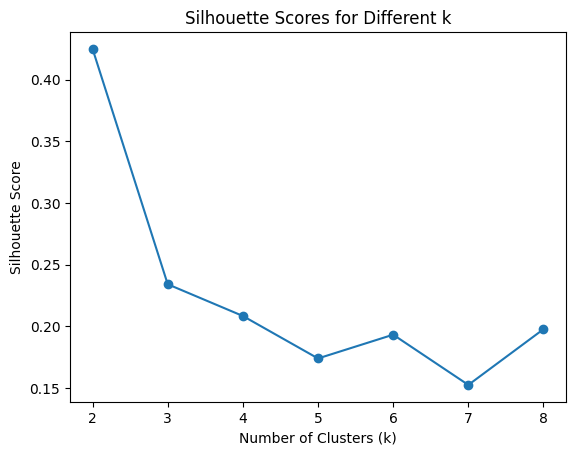

k=2: silhouette score=0.425
k=3: silhouette score=0.234
k=4: silhouette score=0.208
k=5: silhouette score=0.174
k=6: silhouette score=0.193
k=7: silhouette score=0.153
k=8: silhouette score=0.198


In [7]:
 #compute silhouette scores:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")
plt.show()

for k, score in zip(k_values, silhouette_scores):
    print(f"k={k}: silhouette score={score:.3f}")

In [8]:
#6: Fit the final clustering model, for k = 4.

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [9]:
#Check the counts:

df["cluster"].value_counts().sort_index()

cluster
0     8
1     3
2    19
3     1
Name: count, dtype: int64

In [10]:
#7: Profile the clusters, Create a summary table
cluster_profile = df.groupby("cluster")[cluster_features].mean().round(2)
cluster_profile

,age,healthcare_expenses,healthcare_coverage,income,total_encounters,hospitalization_count,total_conditions,unique_conditions,total_medications,unique_medications,total_claims,total_observations
cluster,,,,,,,,,,,,
0,97.84,36896.41,698848.36,20972.88,74.25,3.38,68.00,31.75,143.25,16.62,217.50,2255.50
1,92.53,312439.67,610900.19,70273.00,377.33,2.00,200.33,42.00,755.33,16.00,1132.67,7939.00
2,78.65,200954.63,285471.89,69007.37,47.42,0.68,35.79,22.47,31.37,8.53,78.79,657.89
3,107.82,20829.18,2572940.88,10825.00,71.00,32.00,41.00,27.00,400.00,7.00,471.00,1985.00


In [11]:
#Adding interpretation columns:
df["hospitalization_flag"] = (df["hospitalization_count"] > 0).astype(int)

extra_profile_cols = [
    "high_utilization_flag",
    "high_comorbidity_flag",
    "potential_care_gap_flag",
    "hospitalization_flag"
]
cluster_flags = df.groupby("cluster")[extra_profile_cols].mean().round(2)
cluster_flags

,high_utilization_flag,high_comorbidity_flag,potential_care_gap_flag,hospitalization_flag
cluster,,,,
0,0.38,0.50,0.0,0.75
1,1.00,1.00,0.0,0.67
2,0.05,0.05,0.0,0.37
3,1.00,0.00,0.0,1.00


In [12]:
#Combine them:helps label the segments
cluster_summary = pd.concat([cluster_profile, cluster_flags], axis=1)
cluster_summary


,age,healthcare_expenses,healthcare_coverage,income,total_encounters,hospitalization_count,total_conditions,unique_conditions,total_medications,unique_medications,total_claims,total_observations,high_utilization_flag,high_comorbidity_flag,potential_care_gap_flag,hospitalization_flag
cluster,,,,,,,,,,,,,,,,
0,97.84,36896.41,698848.36,20972.88,74.25,3.38,68.00,31.75,143.25,16.62,217.50,2255.50,0.38,0.50,0.0,0.75
1,92.53,312439.67,610900.19,70273.00,377.33,2.00,200.33,42.00,755.33,16.00,1132.67,7939.00,1.00,1.00,0.0,0.67
2,78.65,200954.63,285471.89,69007.37,47.42,0.68,35.79,22.47,31.37,8.53,78.79,657.89,0.05,0.05,0.0,0.37
3,107.82,20829.18,2572940.88,10825.00,71.00,32.00,41.00,27.00,400.00,7.00,471.00,1985.00,1.00,0.00,0.0,1.00


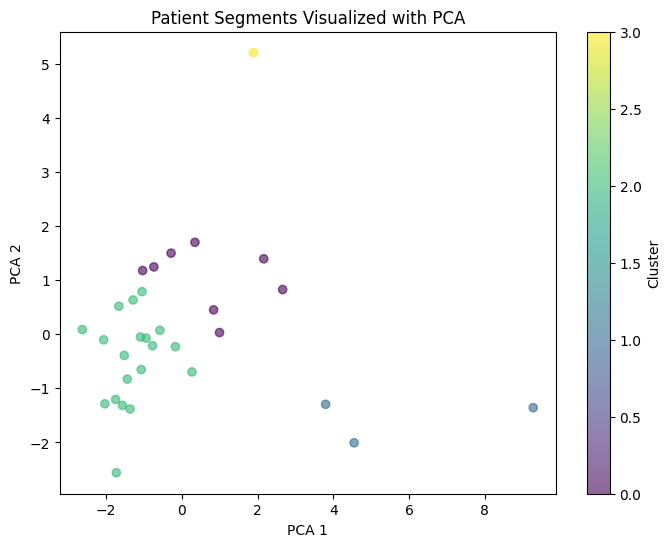

<Figure size 640x480 with 0 Axes>

In [13]:
#8:Visualize clusters with PCA to create a 2D plot.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["pca1"], df["pca2"], c=df["cluster"], alpha=0.6)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Patient Segments Visualized with PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()
plt.savefig("../outputs/figures/patients_segemnts_pca.png", dpi=300, bbox_inches="tight")


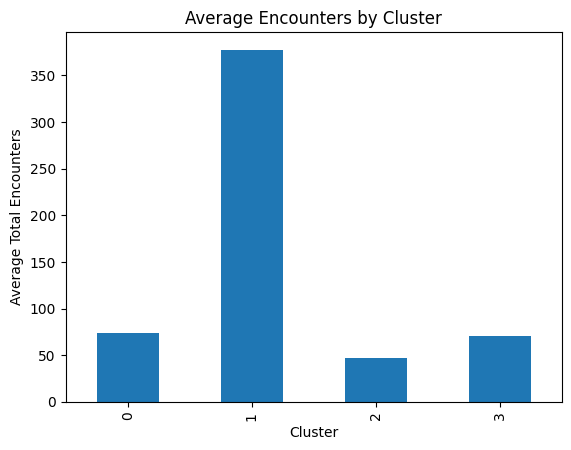

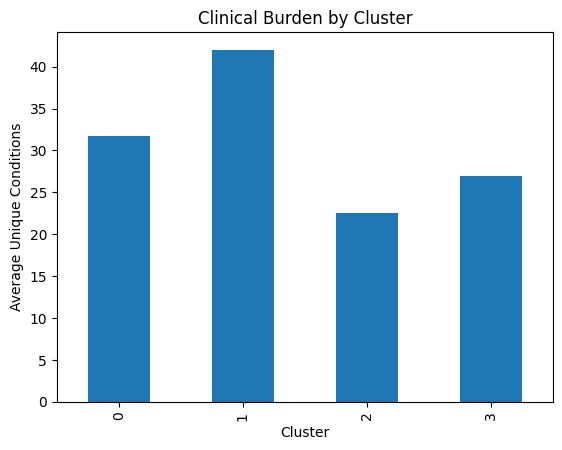

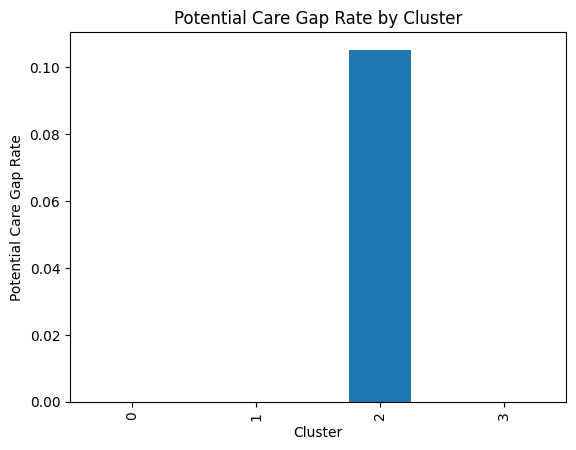

<Figure size 640x480 with 0 Axes>

In [22]:
#9: Compare cluster distributions on key variables.

#Encounters by cluster
df.groupby("cluster")["total_encounters"].mean().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Average Total Encounters")
plt.title("Average Encounters by Cluster")
plt.show()
plt.savefig("../outputs/figures/averagre_total_encounters.png", dpi=300, bbox_inches="tight")

#Conditions by cluster
df.groupby("cluster")["unique_conditions"].mean().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Average Unique Conditions")
plt.title("Clinical Burden by Cluster")
plt.show()
plt.savefig("../outputs/figures/Clinical_Burden_by_Clusters.png", dpi=300, bbox_inches="tight")

#Care gap by cluster
df.groupby("cluster")["potential_care_gap_flag"].mean().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Potential Care Gap Rate")
plt.title("Potential Care Gap Rate by Cluster")
plt.show()
plt.savefig("../outputs/figures/Potential Care Gap Rate by Cluster.png", dpi=300, bbox_inches="tight")


In [15]:
#since my potetial care gap bar chart is empty
print(df["potential_care_gap_flag"].value_counts(dropna=False))
print(df.groupby("cluster")["potential_care_gap_flag"].mean())
print(df.columns.tolist())


potential_care_gap_flag
0    31
Name: count, dtype: int64
cluster
0    0.0
1    0.0
2    0.0
3    0.0
Name: potential_care_gap_flag, dtype: float64
['patient_id_pat', 'birthdate', 'deathdate', 'ssn', 'drivers', 'passport', 'prefix', 'first', 'middle', 'last', 'suffix', 'maiden', 'marital', 'race', 'ethnicity', 'gender', 'birthplace', 'address', 'city', 'state', 'county', 'fips', 'zip', 'lat', 'lon', 'healthcare_expenses', 'healthcare_coverage', 'income', 'age', 'id', 'total_encounters', 'hospitalization_count', 'total_conditions', 'unique_conditions', 'total_medications', 'unique_medications', 'total_claims', 'total_observations', 'age_group', 'high_utilization_flag', 'high_comorbidity_flag', 'potential_care_gap_flag', 'cluster', 'hospitalization_flag', 'pca1', 'pca2']


In [16]:
# fixing it by  redefining my care‑gap logic
df["high_comorbidity_flag"] = (df["unique_conditions"] >= 5).astype(int)
df["low_utilization_flag"] = (df["total_encounters"] < 30).astype(int)

df["potential_care_gap_flag"] = (
    (df["high_comorbidity_flag"] == 1) &
    (df["low_utilization_flag"] == 1)
).astype(int)

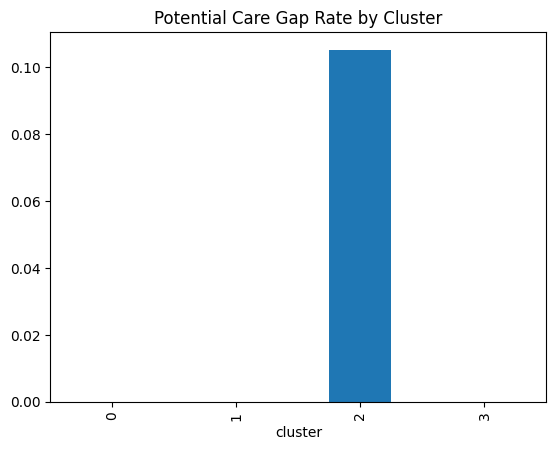

In [17]:
cluster_flags = df.groupby("cluster")[["high_comorbidity_flag", "low_utilization_flag", "potential_care_gap_flag"]].mean().round(2)
cluster_flags
df.groupby("cluster")["potential_care_gap_flag"].mean().plot(kind="bar")
plt.title("Potential Care Gap Rate by Cluster")
plt.show()
#plt.savefig("../output/figures/Potential_CareGap_Rate_by_Cluster.png", dpi=300, bbox_inches="tight")

10: Interpreting the clusters:
## Segment Interpretation

Based on clustering across utilization, condition burden, medication burden, and healthcare resource use, the geriatric population separates into four distinct subgroups:

- **Cluster 0 – Moderate‑Burden, Moderate‑Utilization Patients**  
  Patients with mid‑range condition counts and encounter frequency. They represent a stable, managed population with balanced healthcare engagement.

- **Cluster 1 – High‑Need, High‑Utilization Patients**  
  The most complex group, showing the highest number of conditions and encounters. These patients likely drive the majority of healthcare costs and require intensive management and coordination.

- **Cluster 2 – Potential Care‑Gap Patients**  
  Lower encounter rates despite moderate burden. This group may include individuals who are under‑engaged with care or face barriers to follow‑up — a priority segment for outreach and adherence programs.

- **Cluster 3 – Lower‑Burden, Stable Patients**  
  Fewer conditions and moderate utilization. They represent the healthier end of the geriatric cohort, suitable for preventive and wellness‑focused strategies.

These segments highlight opportunities for targeted population‑health interventions and unmet‑need analytics, particularly Cluster 2, to improve adherence and closing care gaps.


In [18]:
#11: Creating human-readable segment names
cluster_name_map = {
    0: "Moderate‑Burden Stable Patients",
    1: "High‑Need High‑Utilization Patients",
    2: "Potential Care‑Gap Patients",
    3: "Lower‑Burden Stable Patients"
}
df["segment_name"] = df["cluster"].map(cluster_name_map)

In [19]:
df["segment_name"].value_counts()

segment_name
Potential Care‑Gap Patients            19
Moderate‑Burden Stable Patients         8
High‑Need High‑Utilization Patients     3
Lower‑Burden Stable Patients            1
Name: count, dtype: int64

In [20]:
#12: Save the segmented dataset
OUTPUT_PATH = Path("../data/processed/patient_level_segmented.csv")
df.to_csv(OUTPUT_PATH, index=False)

In [21]:
#saving the summary table:
cluster_summary.to_csv("../output/tables/cluster_summary.csv")